In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data1 = pd.read_csv(r'F:\ICT\Beer servings\beer-servings.csv')
data1.head()


,Unnamed: 0,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol,continent
0,0,Afghanistan,0.0,0.0,0.0,0.0,Asia
1,1,Albania,89.0,132.0,54.0,4.9,Europe
2,2,Algeria,25.0,0.0,14.0,0.7,Africa
3,3,Andorra,245.0,138.0,312.0,12.4,Europe
4,4,Angola,217.0,57.0,45.0,5.9,Africa


In [3]:
data1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193 entries, 0 to 192
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Unnamed: 0                    193 non-null    int64  
 1   country                       193 non-null    object 
 2   beer_servings                 185 non-null    float64
 3   spirit_servings               185 non-null    float64
 4   wine_servings                 187 non-null    float64
 5   total_litres_of_pure_alcohol  192 non-null    float64
 6   continent                     193 non-null    object 
dtypes: float64(4), int64(1), object(2)
memory usage: 10.7+ KB


In [4]:
data1['total_litres_of_pure_alcohol'].nunique()

90

In [5]:
# Duplicate Rows
print("Duplicate Rows:", data1.duplicated().sum())
# Remove duplicate rows
data1 = data1.drop_duplicates()

Duplicate Rows: 0


In [6]:
# Duplicate Columns
duplicate_columns = data1.columns[data1.T.duplicated()]
print("Duplicate Columns:")
print(duplicate_columns)
# Remove duplicate columns
data1 = data1.loc[:, ~data1.T.duplicated()]

Duplicate Columns:
Index([], dtype='object')


In [7]:
print("\nMissing Values :")
data1.isna().sum() 


Missing Values :


Unnamed: 0                      0
country                         0
beer_servings                   8
spirit_servings                 8
wine_servings                   6
total_litres_of_pure_alcohol    1
continent                       0
dtype: int64

In [8]:
df1= data1.drop(['Unnamed: 0'],axis = 1)
df1 = df1.dropna(subset=['total_litres_of_pure_alcohol']) # Removed rows where target variable is missing

In [9]:
# Missing numerical columns
missing_num_cols = [col for col in df1.select_dtypes(include=['number']).columns if df1[col].isnull().sum() > 0]

print("Missing Numerical Columns:\n", missing_num_cols)

Missing Numerical Columns:
 ['beer_servings', 'spirit_servings', 'wine_servings']


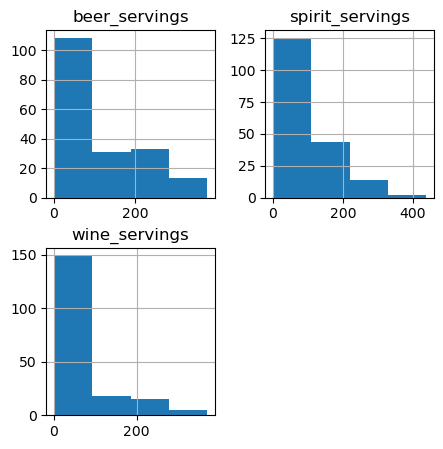

In [10]:
df1[missing_num_cols].hist(figsize=[5,5], bins=4)
plt.show()

In [11]:
# 1.  Missing Continuous numerical features - Median 
# Median is used because Age feature is skewed
for i in ['beer_servings','spirit_servings', 'wine_servings']:
    df1[i] = df1[i].fillna(df1[i].median())

In [12]:
#2. Missing categorical features
# Categorical missing values filled using mode because mode represents the most frequent category
missing_cat_cols = [col for col in df1.select_dtypes(include=['object']).columns 
                   if df1[col].isnull().sum() > 0]
print("\nMissing Categorical Columns:\n", missing_cat_cols)


Missing Categorical Columns:
 []


In [13]:
df1.isna().sum()

country                         0
beer_servings                   0
spirit_servings                 0
wine_servings                   0
total_litres_of_pure_alcohol    0
continent                       0
dtype: int64

In [14]:
numerical_cols = df1.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df1.select_dtypes(include=['object']).columns

print('Numerical Columns:\n', numerical_cols)
print('\nCategorical Columns:\n', categorical_cols)

Numerical Columns:
 Index(['beer_servings', 'spirit_servings', 'wine_servings',
       'total_litres_of_pure_alcohol'],
      dtype='object')

Categorical Columns:
 Index(['country', 'continent'], dtype='object')


In [15]:
df1.shape

(192, 6)

In [16]:
from sklearn.preprocessing import LabelEncoder
le_country = LabelEncoder()
df1['country'] = le_country.fit_transform(df1['country'])

le_continent = LabelEncoder()
df1['continent'] = le_continent.fit_transform(df1['continent'])
#To satisfy the UI requirement of having multiple categorical dropdowns, I retained the 'Country' feature and applied Label Encoding.

In [17]:
df1.head() 

,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol,continent
0,0,0.0,0.0,0.0,0.0,1
1,1,89.0,132.0,54.0,4.9,2
2,2,25.0,0.0,14.0,0.7,0
3,3,245.0,138.0,312.0,12.4,2
4,4,217.0,57.0,45.0,5.9,0


In [18]:
x= df1.drop(['total_litres_of_pure_alcohol'], axis=1)
y=df1['total_litres_of_pure_alcohol']

In [19]:
from sklearn.preprocessing import StandardScaler
num_cols = ['beer_servings', 'spirit_servings', 'wine_servings']
std_scaler = StandardScaler()

In [20]:
x[num_cols] = std_scaler.fit_transform(x[num_cols])
x.head()

,country,beer_servings,spirit_servings,wine_servings,continent
0,0,-1.055835,-0.942781,-0.618585,1
1,1,-0.152827,0.567957,0.061819,2
2,2,-0.802181,-0.942781,-0.442184,0
3,3,1.429975,0.636627,3.312641,2
4,4,1.145882,-0.290416,-0.051582,0


In [21]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2,random_state = 42)
from sklearn.metrics import mean_squared_error, r2_score

In [22]:
def evaluate_model(model):
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print('Mean Squared Error = ', mse)
    print('R Squared Error = ', r2)

### Linear Regression 

In [23]:
print('LINEAR REGRESSION')
from sklearn.linear_model import LinearRegression
lr= LinearRegression()
evaluate_model(lr)

LINEAR REGRESSION
Mean Squared Error =  1.1369881366546888
R Squared Error =  0.932356812948037


### Ridge Regression 

In [24]:
from sklearn.linear_model import Ridge
param_grid = {'alpha': [0.1, 1, 10, 100]}
#Above are the combination of hyperparameter for tuning
from sklearn.model_selection import GridSearchCV
regression = Ridge()
grid_search = GridSearchCV( estimator=regression,param_grid=param_grid,cv=5,scoring='r2')
#Use r2 as the metric to decide which hyperparameters are best.
# verbose=1 Shows progress while Grid Search is running.
grid_search.fit(x_train, y_train) # Train model
# Best parameters
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'alpha': 1}


In [25]:
#Best model
print('RIDGE REGRESSION - CV grid ')
best_r = grid_search.best_estimator_
evaluate_model(best_r)

RIDGE REGRESSION - CV grid 
Mean Squared Error =  1.1387415958072777
R Squared Error =  0.9322524938600687


In [26]:
#I performed a GridSearch for Ridge Regression hyperparameter tuning. 
#While alpha=1 was determined as the optimal value via Cross-Validation, manual testing revealed that alpha=0.1 
#yielded a slightly higher R-squared on the test hold-out set, 
#indicating the model's sensitivity to regularization intensity.

### Lasso Regression 

In [27]:
from sklearn.linear_model import Lasso
param_grid = {'alpha': [0.1, 1, 10, 100]}
#Above are the combination of hyperparameter for tuning
from sklearn.model_selection import GridSearchCV
regression = Lasso()
grid_search = GridSearchCV( estimator=regression,param_grid=param_grid,cv=5,scoring='r2')
#Use r2 as the metric to decide which hyperparameters are best.
# verbose=1 Shows progress while Grid Search is running.
grid_search.fit(x_train, y_train) # Train model
# Best parameters
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'alpha': 0.1}


In [28]:
#Best model
print('LASSO REGRESSIO - CV grid ')
best_l = grid_search.best_estimator_
evaluate_model(best_l)

LASSO REGRESSIO - CV grid 
Mean Squared Error =  1.1983140852460792
R Squared Error =  0.9287083293113372


### Random Forest

In [29]:
from sklearn.ensemble import RandomForestRegressor
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

from sklearn.model_selection import GridSearchCV
regression =  RandomForestRegressor(random_state=42)
grid_search = GridSearchCV( estimator=regression,param_grid=param_grid,cv=5,scoring='r2' ,verbose=1)
#Use r2 as the metric to decide which hyperparameters are best.
# verbose=1 Shows progress while Grid Search is running.
grid_search.fit(x_train, y_train) # Train model
# Best parameters
print("Best Parameters:", grid_search.best_params_)

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}


In [30]:
#Best model
print('RANDOM FOREST- CV grid ')
best_rf = grid_search.best_estimator_
evaluate_model(best_rf)

RANDOM FOREST- CV grid 
Mean Squared Error =  1.5199057564102567
R Squared Error =  0.9095757765030764


In [31]:
def e_model(model):
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    return mse,r2

In [32]:
results = pd.DataFrame(columns=['MSE', 'r2'])
results.loc['LINEAR REGRESSION'] = e_model(LinearRegression())
results.loc['RIDGE REGRESSION'] =  e_model(Ridge(alpha = 1))
results.loc['LASSO REGRESSION'] =  e_model(Lasso(alpha = 0.1))
results.loc['RANDOM FOREST'] =  e_model(RandomForestRegressor(random_state=42,max_depth= None, min_samples_split= 2,n_estimators= 200))
print(results)

                        MSE        r2
LINEAR REGRESSION  1.136988  0.932357
RIDGE REGRESSION   1.138742  0.932252
LASSO REGRESSION   1.198314  0.928708
RANDOM FOREST      1.519906  0.909576


In [1]:
#Four regression models were trained and evaluated: Linear Regression, Ridge Regression,
#Lasso Regression, and Random Forest Regression. The selection criterion was the R² score on the test dataset. 
#Linear Regression achieved the highest R² score of 0.932357 and the lowest Mean Squared Error of 1.136988. 
#Therefore, Linear Regression was selected 
#as the final model for deployment in the Flask web application.